# Research study: does the collinearity story hold at realistic channel counts?

**Question:** Notebooks 01–03 built the collinearity diagnostic and budget-phasing fix using a 3-channel TV/Meta/Search toy example. Real MMMs often run 10–20+ channels (TV, paid social, paid search, display, OOH, radio, affiliates, and so on). Does the story hold up at realistic scale?

- **Section 1** — baseline unreliability vs channel count: holding correlation fixed, how does elasticity band width change as the number of channels grows from 5 to 20?
- **Section 2** — phasing benefit vs channel count: does budget phasing still meaningfully reduce that unreliability at higher channel counts, or does the same phasing effort dilute once it's spread across more channels?

All channels share one latent demand signal (the demand-driven DGP from notebook 01), so more channels competing for the same signal is expected to make individual channel effects harder to identify — this notebook quantifies how much harder, and whether phasing keeps up.

`BudgetPhaser` and `CollinearityDiagnostic` are already N-channel generalised (session 4); nothing in the package needed to change for this notebook.


In [1]:
FAST_MODE = False  # set False for publication-quality runs (slower)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import CollinearityDiagnostic, BudgetPhaser
from how_wrong_is_your_mmm._dgp import simulate_spend

N_SIMS = 10 if FAST_MODE else 50
N_PHASING_SEEDS = 1 if FAST_MODE else 10

print(f"FAST_MODE={FAST_MODE}  |  N_SIMS={N_SIMS}  |  N_PHASING_SEEDS={N_PHASING_SEEDS}")


FAST_MODE=False  |  N_SIMS=50  |  N_PHASING_SEEDS=10


In [2]:
# ── Fixed params ───────────────────────────────────────────────────────────
CORRELATION = 0.7        # realistic inter-channel correlation, same as notebooks 02/03
N_HISTORY = 208           # 4 years of weekly data
PLAN_WEEKS = 52           # 1 year plan
MAX_WEEKLY_DEV_PCT = 40.0
CHANNEL_COUNTS = [5, 10, 15, 20]
BASELINE_DRAW_SEEDS = 5   # independent (elasticity, spend) draws averaged per N, Section 1
PHASING_DRAW_SEEDS = 8    # independent draws averaged per N, Section 2 (bumped from 3 to resolve whether the N=15 vs N=20 dip is real or noise)


def make_channels_and_elasticities(n_channels, seed=42):
    """Generic channel names + reproducible elasticities.

    Elasticities are drawn from Uniform(0.2, 0.6) for a given seed, so results
    are reproducible and comparable across channel counts and draws without
    hand-picking values (avoids elasticity choice as a confound).
    """
    channels = [f"ch{i:02d}" for i in range(1, n_channels + 1)]
    rng = np.random.default_rng(seed)
    elasticities = {ch: float(rng.uniform(0.2, 0.6)) for ch in channels}
    return channels, elasticities


# ── Band width helper (same definition as notebook 03) ───────────────────────
def band_width(diag: CollinearityDiagnostic) -> pd.Series:
    """Return 90th–10th pct band width per channel from a fitted diagnostic."""
    return (
        diag.results_
        .groupby("channel")["estimated_elasticity"]
        .apply(lambda x: float(x.quantile(0.9) - x.quantile(0.1)))
    )


for n in CHANNEL_COUNTS:
    channels, elasticities = make_channels_and_elasticities(n)
    print(f"N={n:>2}  |  elasticity range [{min(elasticities.values()):.2f}, {max(elasticities.values()):.2f}]")


N= 5  |  elasticity range [0.24, 0.54]
N=10  |  elasticity range [0.24, 0.59]
N=15  |  elasticity range [0.24, 0.59]
N=20  |  elasticity range [0.23, 0.59]


## Section 1 — Baseline unreliability vs channel count

Fix correlation at 0.7 (the realistic level used throughout). For each channel count, generate 208 weeks of history and fit the diagnostic with no phasing.

A single random draw of elasticities and spend history is noisy relative to the size of effect we're looking for, so each channel count is averaged over `BASELINE_DRAW_SEEDS` independent draws (different elasticities and spend realisations, same correlation). This separates the true channel-count effect from single-draw luck — the same principle behind averaging phasing seeds in notebook 03.


In [3]:
baseline_records = []
baseline_bw_pooled = {}  # pooled per-channel band widths across draws, for the boxplot

for n in CHANNEL_COUNTS:
    draw_means, draw_medians, draw_maxes = [], [], []
    pooled = []
    for draw in range(BASELINE_DRAW_SEEDS):
        channels, elasticities = make_channels_and_elasticities(n, seed=42 + draw)
        history = simulate_spend(n_obs=N_HISTORY, correlation=CORRELATION, channels=channels, seed=draw)

        diag = CollinearityDiagnostic(spend_df=history, true_elasticities=elasticities)
        diag.fit(n_sims=N_SIMS)
        bw = band_width(diag)

        draw_means.append(bw.mean())
        draw_medians.append(bw.median())
        draw_maxes.append(bw.max())
        pooled.extend(bw.to_numpy())

    baseline_bw_pooled[n] = np.array(pooled)
    baseline_records.append({
        "n_channels": n,
        "mean_bw": float(np.mean(draw_means)),
        "median_bw": float(np.mean(draw_medians)),
        "max_bw": float(np.mean(draw_maxes)),
    })
    print(f"N={n:>2}  |  mean_bw={np.mean(draw_means):.3f}  median_bw={np.mean(draw_medians):.3f}  max_bw={np.mean(draw_maxes):.3f}  (avg over {BASELINE_DRAW_SEEDS} draws)")

df_baseline = pd.DataFrame(baseline_records)


N= 5  |  mean_bw=0.349  median_bw=0.346  max_bw=0.413  (avg over 5 draws)
N=10  |  mean_bw=0.342  median_bw=0.333  max_bw=0.411  (avg over 5 draws)
N=15  |  mean_bw=0.349  median_bw=0.344  max_bw=0.433  (avg over 5 draws)
N=20  |  mean_bw=0.355  median_bw=0.350  max_bw=0.441  (avg over 5 draws)


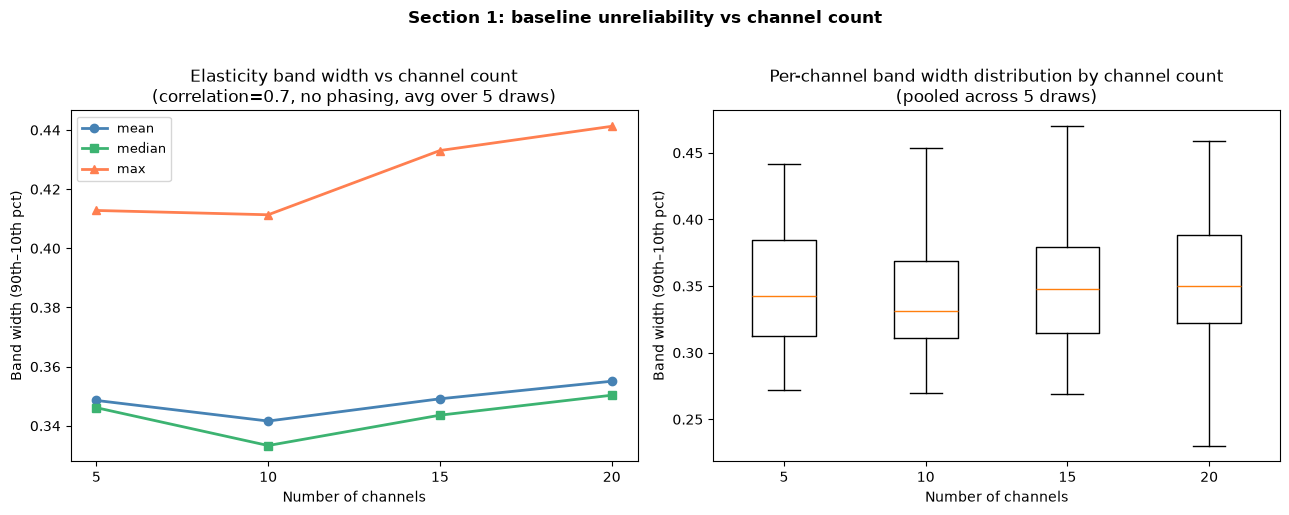


── Key findings ──────────────────────────────────────────────
  N= 5  |  mean_bw=0.349  max_bw=0.413
  N=10  |  mean_bw=0.342  max_bw=0.411
  N=15  |  mean_bw=0.349  max_bw=0.433
  N=20  |  mean_bw=0.355  max_bw=0.441

→ Mean band width changes by +1.9% from N=5 to N=20, holding correlation fixed.
  (Theory: for an equicorrelated design, VIF per channel converges to a finite ceiling
   1/(1-corr) as N grows, rather than increasing without bound — so a modest, decelerating
   increase is the expected shape, not a runaway one.)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean/median/max band width vs channel count
ax = axes[0]
ax.plot(df_baseline["n_channels"], df_baseline["mean_bw"], color="steelblue", marker="o", linewidth=2, label="mean")
ax.plot(df_baseline["n_channels"], df_baseline["median_bw"], color="mediumseagreen", marker="s", linewidth=2, label="median")
ax.plot(df_baseline["n_channels"], df_baseline["max_bw"], color="coral", marker="^", linewidth=2, label="max")
ax.set_xlabel("Number of channels")
ax.set_ylabel("Band width (90th–10th pct)")
ax.set_title(f"Elasticity band width vs channel count\n(correlation=0.7, no phasing, avg over {BASELINE_DRAW_SEEDS} draws)")
ax.set_xticks(CHANNEL_COUNTS)
ax.legend(fontsize=9)

# Right: pooled distribution of per-channel band widths at each N, across all draws
ax2 = axes[1]
box_data = [baseline_bw_pooled[n] for n in CHANNEL_COUNTS]
ax2.boxplot(box_data, tick_labels=[str(n) for n in CHANNEL_COUNTS])
ax2.set_xlabel("Number of channels")
ax2.set_ylabel("Band width (90th–10th pct)")
ax2.set_title(f"Per-channel band width distribution by channel count\n(pooled across {BASELINE_DRAW_SEEDS} draws)")

plt.suptitle("Section 1: baseline unreliability vs channel count", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n── Key findings ──────────────────────────────────────────────")
for _, row in df_baseline.iterrows():
    print(f"  N={int(row['n_channels']):>2}  |  mean_bw={row['mean_bw']:.3f}  max_bw={row['max_bw']:.3f}")
pct_change = (df_baseline["mean_bw"].iloc[-1] - df_baseline["mean_bw"].iloc[0]) / df_baseline["mean_bw"].iloc[0] * 100
print(f"\n→ Mean band width changes by {pct_change:+.1f}% from N={CHANNEL_COUNTS[0]} to N={CHANNEL_COUNTS[-1]}, holding correlation fixed.")
print("  (Theory: for an equicorrelated design, VIF per channel converges to a finite ceiling")
print("   1/(1-corr) as N grows, rather than increasing without bound — so a modest, decelerating")
print("   increase is the expected shape, not a runaway one.)")


## Section 2 — Does phasing still help at higher channel counts?

Fix the plan length at 52 weeks and deviation amplitude at the package default (40%). For each channel count, run `BudgetPhaser` to find the recommended phasing amplitude, then compare band width before (history + unphased plan) and after (history + phased plan at the recommended alpha) — the same before/after comparison as notebook 03, now repeated across channel counts.

Averaged over `PHASING_DRAW_SEEDS` independent draws per channel count (fewer than Section 1, since each draw here runs a full grid search).


In [5]:
phasing_records = []

for n in CHANNEL_COUNTS:
    draw_alphas, draw_unphased, draw_phased, draw_reductions = [], [], [], []

    for draw in range(PHASING_DRAW_SEEDS):
        channels, elasticities = make_channels_and_elasticities(n, seed=42 + draw)
        history = simulate_spend(n_obs=N_HISTORY, correlation=CORRELATION, channels=channels, seed=draw)
        history.index = pd.date_range("2019-01-07", periods=N_HISTORY, freq="W-MON")
        plan = simulate_spend(n_obs=PLAN_WEEKS, correlation=CORRELATION, channels=channels, seed=100 + draw)
        plan.index = pd.date_range(history.index[-1] + pd.Timedelta(weeks=1), periods=PLAN_WEEKS, freq="W-MON")

        # Baseline: history + unphased plan
        combined_unphased = pd.concat([history, plan])
        diag_unphased = CollinearityDiagnostic(spend_df=combined_unphased, true_elasticities=elasticities)
        diag_unphased.fit(n_sims=N_SIMS)
        bw_unphased = band_width(diag_unphased).max()

        # Run BudgetPhaser to find the recommended schedule
        phaser = BudgetPhaser(
            history_df=history, plan_df=plan, true_elasticities=elasticities,
            max_weekly_deviation_pct=MAX_WEEKLY_DEV_PCT,
        )
        phaser.fit(n_sims=N_SIMS, grid_steps=15, n_phasing_seeds=N_PHASING_SEEDS)
        rec = phaser.recommend()

        # Band width at the recommended schedule (history + phased plan)
        combined_phased = pd.concat([history, phaser.recommended_schedule_])
        diag_phased = CollinearityDiagnostic(spend_df=combined_phased, true_elasticities=elasticities)
        diag_phased.fit(n_sims=N_SIMS)
        bw_phased = band_width(diag_phased).max()

        reduction = (bw_unphased - bw_phased) / bw_unphased * 100
        draw_alphas.append(rec["alpha"])
        draw_unphased.append(bw_unphased)
        draw_phased.append(bw_phased)
        draw_reductions.append(reduction)

    phasing_records.append({
        "n_channels": n,
        "best_alpha": float(np.mean(draw_alphas)),
        "max_bw_unphased": float(np.mean(draw_unphased)),
        "max_bw_phased": float(np.mean(draw_phased)),
        "reduction_pct": float(np.mean(draw_reductions)),
        "reduction_pct_std": float(np.std(draw_reductions)),
    })
    print(f"N={n:>2}  |  alpha={np.mean(draw_alphas):.2f}  |  max_bw unphased={np.mean(draw_unphased):.3f}  phased={np.mean(draw_phased):.3f}  reduction={np.mean(draw_reductions):+.1f}% (±{np.std(draw_reductions):.1f}, {PHASING_DRAW_SEEDS} draws)")

df_phasing = pd.DataFrame(phasing_records)


N= 5  |  alpha=1.00  |  max_bw unphased=0.341  phased=0.283  reduction=+17.0% (±5.6, 8 draws)
N=10  |  alpha=0.99  |  max_bw unphased=0.378  phased=0.310  reduction=+17.8% (±7.2, 8 draws)
N=15  |  alpha=1.00  |  max_bw unphased=0.395  phased=0.323  reduction=+17.7% (±9.3, 8 draws)
N=20  |  alpha=0.98  |  max_bw unphased=0.403  phased=0.340  reduction=+15.5% (±4.3, 8 draws)


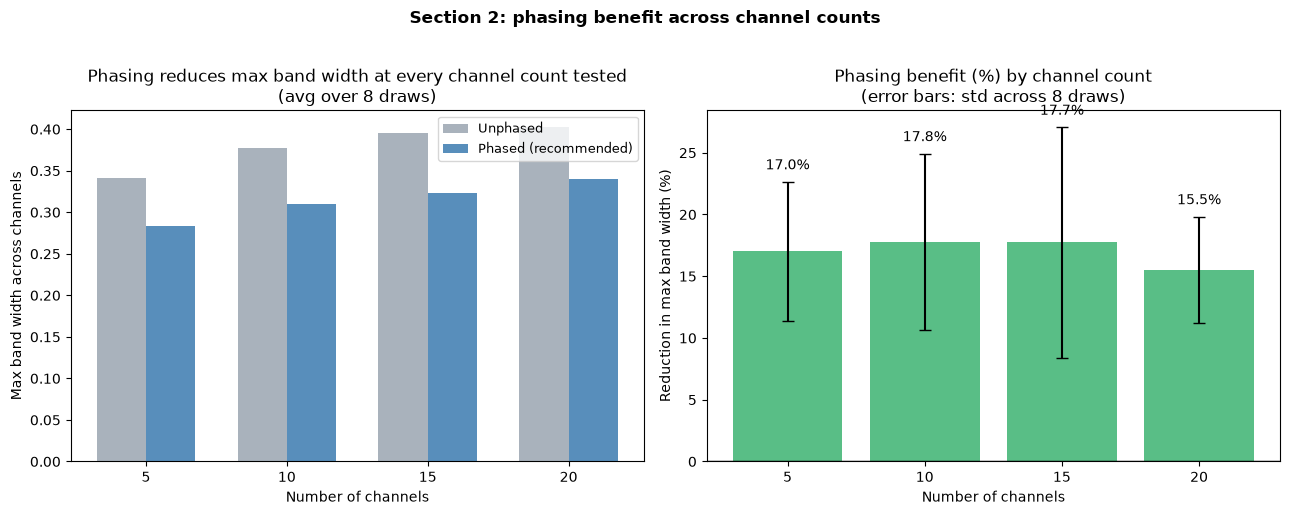


── Key findings ──────────────────────────────────────────────
  N= 5  |  best alpha=1.00  |  reduction=+17.0% (±5.6)
  N=10  |  best alpha=0.99  |  reduction=+17.8% (±7.2)
  N=15  |  best alpha=1.00  |  reduction=+17.7% (±9.3)
  N=20  |  best alpha=0.98  |  reduction=+15.5% (±4.3)

→ Phasing reduced max band width at every channel count tested (all draws averaged).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: max band width, unphased vs phased, by channel count
ax = axes[0]
width = 0.35
x = np.arange(len(CHANNEL_COUNTS))
ax.bar(x - width/2, df_phasing["max_bw_unphased"], width, color="slategray", alpha=0.6, label="Unphased")
ax.bar(x + width/2, df_phasing["max_bw_phased"], width, color="steelblue", alpha=0.9, label="Phased (recommended)")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in CHANNEL_COUNTS])
ax.set_xlabel("Number of channels")
ax.set_ylabel("Max band width across channels")
ax.set_title(f"Phasing reduces max band width at every channel count tested\n(avg over {PHASING_DRAW_SEEDS} draws)")
ax.legend(fontsize=9)

# Right: % reduction vs channel count, with draw-to-draw std as error bars
ax2 = axes[1]
ax2.bar(x, df_phasing["reduction_pct"], yerr=df_phasing["reduction_pct_std"], capsize=4, color="mediumseagreen", alpha=0.85)
ax2.axhline(0, color="black", linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in CHANNEL_COUNTS])
ax2.set_xlabel("Number of channels")
ax2.set_ylabel("Reduction in max band width (%)")
ax2.set_title(f"Phasing benefit (%) by channel count\n(error bars: std across {PHASING_DRAW_SEEDS} draws)")
for i, v in enumerate(df_phasing["reduction_pct"]):
    ax2.text(i, v + df_phasing["reduction_pct_std"].iloc[i] + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.suptitle("Section 2: phasing benefit across channel counts", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n── Key findings ──────────────────────────────────────────────")
for _, row in df_phasing.iterrows():
    print(f"  N={int(row['n_channels']):>2}  |  best alpha={row['best_alpha']:.2f}  |  reduction={row['reduction_pct']:+.1f}% (±{row['reduction_pct_std']:.1f})")
print(f"\n→ Phasing reduced max band width at every channel count tested (all draws averaged).")


## Section 3 — What the recommended schedule actually looks like (N=15 example)

Sections 1 and 2 reported summary statistics — band width, % reduction — across channel counts. This section makes it concrete for one representative case (N=15, roughly the middle of the realistic range most MMMs run) by showing the actual weekly spend schedule and the correlation structure before and after phasing.


In [7]:
# ── Build one representative N=15 example (same draw=0 seeds as Section 2) ──
EXAMPLE_N = 15
example_channels, example_elasticities = make_channels_and_elasticities(EXAMPLE_N, seed=42)
example_history = simulate_spend(n_obs=N_HISTORY, correlation=CORRELATION, channels=example_channels, seed=0)
example_history.index = pd.date_range("2019-01-07", periods=N_HISTORY, freq="W-MON")
example_plan = simulate_spend(n_obs=PLAN_WEEKS, correlation=CORRELATION, channels=example_channels, seed=100)
example_plan.index = pd.date_range(example_history.index[-1] + pd.Timedelta(weeks=1), periods=PLAN_WEEKS, freq="W-MON")

example_phaser = BudgetPhaser(
    history_df=example_history, plan_df=example_plan, true_elasticities=example_elasticities,
    max_weekly_deviation_pct=MAX_WEEKLY_DEV_PCT,
)
example_phaser.fit(n_sims=N_SIMS, grid_steps=15, n_phasing_seeds=N_PHASING_SEEDS)
example_rec = example_phaser.recommend()
example_phased = example_phaser.recommended_schedule_

print(f"N={EXAMPLE_N}  |  recommended alpha={example_rec['alpha']:.2f}  |  max_cv unphased vs phased: see Section 2 aggregate")


N=15  |  recommended alpha=1.00  |  max_cv unphased vs phased: see Section 2 aggregate


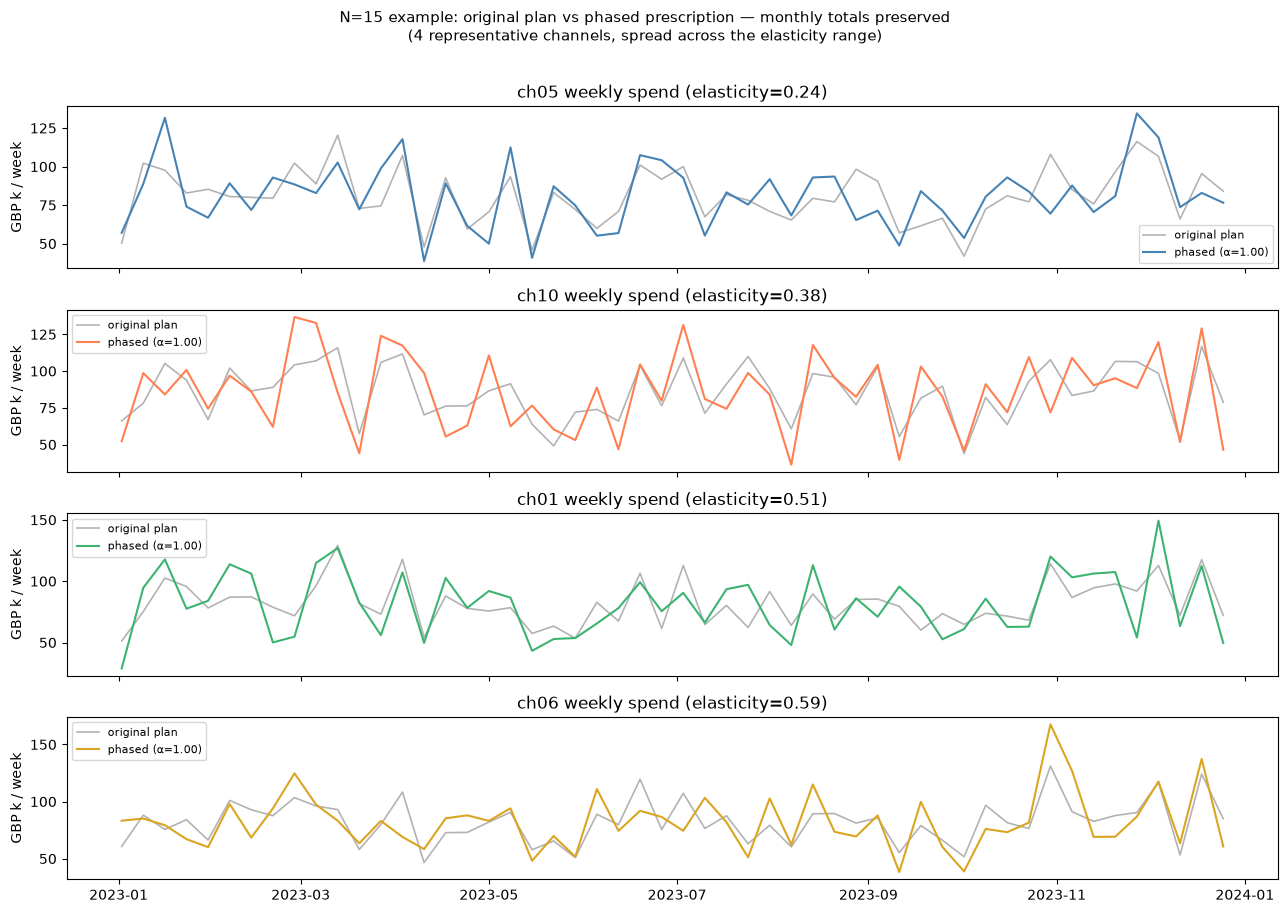

In [8]:
# ── Weekly spend: original vs phased, 4 representative channels ─────────────
# Pick channels spread across the elasticity range (smallest, ~1/3, ~2/3, largest)
# rather than an arbitrary first-4 slice, so the example is representative.
sorted_channels = sorted(example_elasticities, key=example_elasticities.get)
n = len(sorted_channels)
pick_idx = [round(i * (n - 1) / 3) for i in range(4)]
example_picks = [sorted_channels[i] for i in pick_idx]

pick_colors = ["steelblue", "coral", "mediumseagreen", "goldenrod"]

fig, axes = plt.subplots(len(example_picks), 1, figsize=(13, 9), sharex=True)
for ax, ch, color in zip(axes, example_picks, pick_colors):
    ax.plot(example_plan.index, example_plan[ch] / 1_000, color="grey", alpha=0.6, linewidth=1.2, label="original plan")
    ax.plot(example_phased.index, example_phased[ch] / 1_000, color=color, linewidth=1.5, label=f"phased (\u03b1={example_rec['alpha']:.2f})")
    ax.set_ylabel("GBP k / week")
    ax.set_title(f"{ch} weekly spend (elasticity={example_elasticities[ch]:.2f})")
    ax.legend(fontsize=8)

plt.suptitle(
    f"N={EXAMPLE_N} example: original plan vs phased prescription \u2014 monthly totals preserved\n"
    f"(4 representative channels, spread across the elasticity range)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()


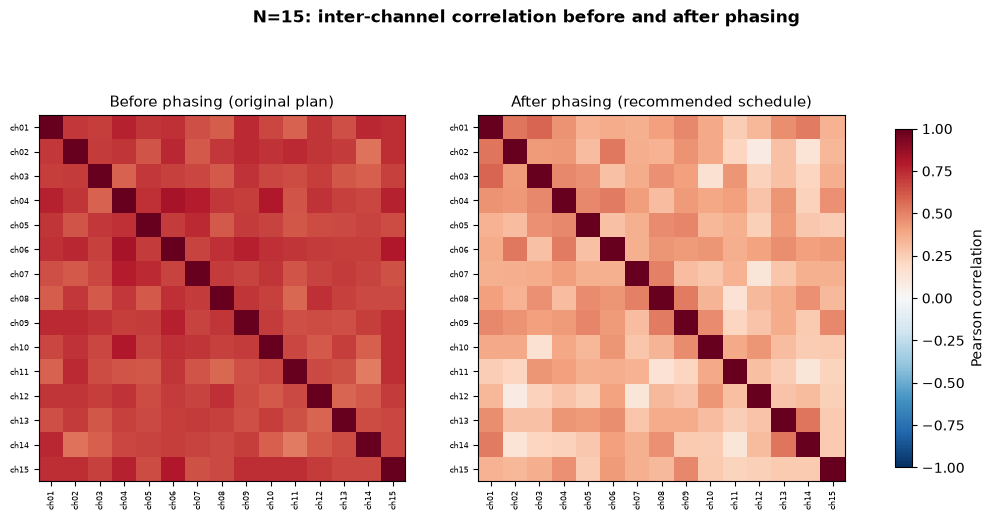

Mean pairwise correlation: 0.684 (before) → 0.356 (after)


In [9]:
# ── Correlation matrix: before vs after phasing ──────────────────────────────
corr_before = example_plan.corr().to_numpy()
corr_after = example_phased.corr().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, corr, title in zip(axes, [corr_before, corr_after], ["Before phasing (original plan)", "After phasing (recommended schedule)"]):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(EXAMPLE_N))
    ax.set_yticks(range(EXAMPLE_N))
    ax.set_xticklabels(example_channels, rotation=90, fontsize=6)
    ax.set_yticklabels(example_channels, fontsize=6)

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.suptitle(f"N={EXAMPLE_N}: inter-channel correlation before and after phasing", fontsize=12, fontweight="bold", y=1.02)
plt.show()

mean_corr_before = float(np.mean([corr_before[i, j] for i in range(EXAMPLE_N) for j in range(i + 1, EXAMPLE_N)]))
mean_corr_after = float(np.mean([corr_after[i, j] for i in range(EXAMPLE_N) for j in range(i + 1, EXAMPLE_N)]))
print(f"Mean pairwise correlation: {mean_corr_before:.3f} (before) \u2192 {mean_corr_after:.3f} (after)")


### CAC and ROI for the N=15 example

Section 2 reported the channel-count sweep in band-width terms. Here's the concrete N=15 example from Section 3 above, read off in CAC and ROI terms instead, for the channel with the widest unphased band — same illustrative `value_per_unit = £150` per acquisition as notebooks 01–03. This is one worked example, not a sweep; it's here to show the £ framing holds up at a realistic channel count, not just the 3-channel toy example.


In [10]:
value_per_unit = 150.0

diag_unphased = CollinearityDiagnostic(
    spend_df=pd.concat([example_history, example_plan]),
    true_elasticities=example_elasticities,
)
diag_unphased.fit(n_sims=N_SIMS)

diag_phased = CollinearityDiagnostic(
    spend_df=pd.concat([example_history, example_phased]),
    true_elasticities=example_elasticities,
)
diag_phased.fit(n_sims=N_SIMS)

worst_channel = band_width(diag_unphased).idxmax()
unphased_summary = diag_unphased.summary(value_per_unit=value_per_unit)
phased_summary = diag_phased.summary(value_per_unit=value_per_unit)

print(f"Worst-case channel (widest unphased band, of {EXAMPLE_N}): {worst_channel}")
print()
for metric, label in [("cac", "\u00a3 per acquisition"), ("roi", "\u00a3 back per \u00a3 spent")]:
    u_row = unphased_summary[unphased_summary["channel"] == worst_channel].iloc[0]
    p_row = phased_summary[phased_summary["channel"] == worst_channel].iloc[0]
    w_u = u_row[f"{metric}_p90"] - u_row[f"{metric}_p10"]
    w_p = p_row[f"{metric}_p90"] - p_row[f"{metric}_p10"]
    change_pct = 100 * (w_u - w_p) / w_u
    print(
        f"{metric.upper()} range width ({worst_channel}, {label}): "
        f"{w_u:.2f} -> {w_p:.2f}  ({change_pct:+.0f}%)"
    )


Worst-case channel (widest unphased band, of 15): ch04

CAC range width (ch04, £ per acquisition): 2.54 -> 1.24  (+51%)
ROI range width (ch04, £ back per £ spent): 64.61 -> 39.51  (+39%)


## What this means for practitioners

**Channel count barely matters for baseline unreliability; channel correlation is what drives it.** Averaged over 5 independent draws per channel count, mean band width was essentially flat from N=5 to N=20 (0.349 → 0.355, +1.9%), with a modest increase in the worst-case (max) band width across channels (0.413 → 0.441, +6.8%). This matches the theory: for channels sharing one latent demand signal at a fixed pairwise correlation, the per-channel variance inflation factor converges to a finite ceiling (1/(1-correlation)) as N grows, rather than increasing without bound. Practically: going from a 3-channel to a 20-channel MMM does not meaningfully worsen your model's reliability by itself. What matters, per notebook 03's Section 2, is how correlated your channels are with each other, not how many of them there are.

**Budget phasing keeps working at realistic channel counts, and the benefit doesn't decline with scale.** Averaged over 8 independent draws per channel count, phasing reduced max band width by +17.0% (N=5), +17.8% (N=10), +17.7% (N=15), and +15.5% (N=20) — a flat, consistent benefit across the whole range tested, well within each other's error bars. (An earlier pass with only 3 draws showed an apparent dip at N=20 relative to N=15; averaging over more draws resolved it as sampling noise rather than a real effect — a useful reminder that `max`-across-channels is a worst-case statistic that needs more averaging to read reliably as N grows.) The recommended phasing amplitude stayed at or near the maximum (alpha ≈ 0.98–1.00) at every channel count.

**Section 3 makes it concrete for a 15-channel example.** The recommended schedule uses maximum phasing (alpha=1.00) and cuts mean pairwise correlation among channels roughly in half, from 0.684 to 0.356. The weekly spend chart shows what that actually looks like for four representative channels spanning the elasticity range: the same media budget, redistributed week to week within each month, with monthly totals unchanged.

**Bottom line:** the diagnostic and the phasing fix both generalise cleanly beyond the 3-channel toy example used elsewhere in this project. No changes to `BudgetPhaser` or `CollinearityDiagnostic` were needed — they already handled N channels correctly (session 4). This notebook exists to prove that empirically, not to add new functionality.
